# **Behind the Wheel : A Data Story of Traffic Collisions in California**

 **Subject:** ISBA 2401: Data Analytics with Python

### **Table of Contents**
1. [Research Question & Hypotheses](#research-question)
2. [Data Preparation](#data-preparation)
3. [Geographic Distribution](#geo-distribution)
4. [Demographics Distribution](#demographics)
5. [Driver Behaviors & Collision Factors](#driver-behaviors)
6. [Conclusion](#conclusion)

### **1. Research Question & Hypotheses**

**Main Research Question:** What patterns and trends can be identified in California traffic collisions from 2020 to 2025, and how do demographic and environmental factors influence the frequency and severity of crashes?

**Hypotheses:**
* **H1:** Urban areas experience a higher frequency of collisions compared to rural areas due to higher traffic density.

* **H2:** Severe weather conditions (rain, fog) increase the likelihood of collisions compared to clear conditions.

* **H3:** Collisions involving impaired driving and speeding result in a higher proportion of severe injuries/fatalities.

**Data Description & Source:**
The dataset was sourced from the California Highway Patrol (CHP) Traffic Records System via the California Open Data Portal. It contains records of traffic collisions occurring in California from 2020 to 2025.
* **Source Link:** [California Collision Record System (CCRS)](https://data.ca.gov/dataset/ccrs)

**Unit of Analysis:**
The unit of analysis is a single traffic collision event.

**Data Dictionary (Key Variables):**
* **CollisionId:** Unique identifier for each crash event.

* **Severity_Score:** A calculated metric where Injury = 1 and Fatality = 3 (used to measure crash impact).

* **Primary_Collision_Factor:** The main legal violation that caused the crash (e.g., Speeding, DUI).

* **PartyType:** Describes the entity involved (Driver, Pedestrian, Parked Vehicle).

* **StatedAge / GenderDescription:** Demographic details of the individuals involved.

* **Weather_1 / Lighting:** Environmental conditions at the time of the crash.

<a id="data-preparation"></a>
### **2. Data Preparation**

In this section, we load the merged datasets for Crashes and Parties, apply necessary cleaning rules, mapping dictionaries and merge the files into a master dataset for analysis.

#### 2.1. Import Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set_theme(style="whitegrid")

#### 2.2. Loading Dataset

In [2]:
# 1. Load the Crashes File 
c_file = "merged_c_merge.csv"
df_crashes = pd.read_csv(c_file, low_memory=False)

# 2. Load the Parties File
p_file = "merged_p_merge.csv"
df_parties = pd.read_csv(p_file, low_memory=False)


#### 2.3. Mapping Rulebook (Renaming)

In [3]:
#County Mapping
county_map = {
    1: "Alameda", 2: "Alpine", 3: "Amador", 4: "Butte",
    5: "Calaveras", 6: "Colusa", 7: "Contra Costa", 8: "Del Norte",
    9: "El Dorado", 10: "Fresno", 11: "Glenn", 12: "Humboldt",
    13: "Imperial", 14: "Inyo", 15: "Kern", 16: "Kings",
    17: "Lake", 18: "Lassen", 19: "Los Angeles", 20: "Madera",
    21: "Marin", 22: "Mariposa", 23: "Mendocino", 24: "Merced",
    25: "Modoc", 26: "Mono", 27: "Monterey", 28: "Napa",
    29: "Nevada", 30: "Orange", 31: "Placer", 32: "Plumas",
    33: "Riverside", 34: "Sacramento", 35: "San Benito", 36: "San Bernardino",
    37: "San Diego", 38: "San Francisco", 39: "San Joaquin", 40: "San Luis Obispo",
    41: "San Mateo", 42: "Santa Barbara", 43: "Santa Clara", 44: "Santa Cruz",
    45: "Shasta", 46: "Sierra", 47: "Siskiyou", 48: "Solano",
    49: "Sonoma", 50: "Stanislaus", 51: "Sutter", 52: "Tehama",
    53: "Trinity", 54: "Tulare", 55: "Tuolumne", 56: "Ventura",
    57: "Yolo", 58: "Yuba"
}

#Primary Collision Factors Mapping
pcf_rename_map = {
    "VC 22350": "Speeding (Basic Speed Law)",
    "22350": "Speeding (Basic Speed Law)",
    "VC 22107": "Unsafe Turning",
    "22107": "Unsafe Turning",
    "VC 21658(A)": "Unsafe Lane Change",
    "21658(A)": "Unsafe Lane Change",
    "VC 23152(a)": "DUI - Alcohol",
    "23152(a)": "DUI - Alcohol",
    "23152A": "DUI - Alcohol",
    "23152A": "DUI - Alcohol",
    "21453A": "Red Light Violation",
    "21453(A)": "Red Light Violation",
    "22106": "Unsafe Starting or Backing",
    "VC 22106": "Unsafe Starting or Backing"
}

#Severity Mapping
severity_map = {
    
    "21640(A)VC": "Driving on Wrong Side",
    "CROSS DOUBLE YELLOW LINES": "Crossed Double Yellow Lines",
    "VC 21460(A) VEHICLE CROSS DOUBLE SOLID YELLOW LINE": "Crossed Double Yellow Lines",
    "CROSS INTO ONCOMING LANE": "Crossed into Oncoming Lane",
    "FAIL TO YIELD RIGHT OF WAY": "Failure to Yield",
    "21802(A)CVC": "Failure to Yield (Stop Sign)",
    "21802 (A)VC": "Failure to Yield (Stop Sign)",
    "VC 23153(F) DUI ALC/DRUG:CAUS BOD INJ": "DUI (Alcohol)",
    "21353F": "DUI (Alcohol)",
    "VC 23152(f) vc": "DUI (Drugs)",
    "23152(f": "DUI (Drugs)",
    "22540": "Illegal Stop on Freeway",
    "21453(A)  CVC": "Red Light Violation",
    "CVC 12453 (a)": "Red Light Violation",
    "22180D": "Unsafe Turn"
}

#### 2.4. Standardize and Create Severity Score

Severity = Number of Injured + (3 * Number of Killed) 

This is a common method used when looking at traffic safety analytics, where each injury = 1 point and each fatality = 3 points.

In [4]:
#Standardize Column Names
df_crashes.columns = df_crashes.columns.str.strip().str.replace(' ', '_').str.replace('/', '_')
df_parties.columns = df_parties.columns.str.strip().str.replace(' ', '_').str.replace('/', '_')

#Rename Collision ID
rename_map = {'Collision_ID': 'CollisionId', 'Collision_Id': 'CollisionId'}
df_crashes = df_crashes.rename(columns=rename_map)
df_parties = df_parties.rename(columns=rename_map)

#Create Severity Score
df_crashes['NumberInjured'] = pd.to_numeric(df_crashes['NumberInjured'], errors='coerce').fillna(0)
df_crashes['NumberKilled'] = pd.to_numeric(df_crashes['NumberKilled'], errors='coerce').fillna(0)
df_crashes['Severity_Score'] = df_crashes['NumberInjured'] + (3 * df_crashes['NumberKilled'])

#### 2.5. Merge Parties onto Crashes (using CollisionID)

In [5]:
df_master = pd.merge(df_parties, df_crashes, on='CollisionId', how='left', suffixes=('_party', '_crash'))

print(f"Master Merged Dataset Shape: {df_master.shape}")
df_master.head()

Master Merged Dataset Shape: (4589823, 127)


,PartyId,CollisionId,PartyNumber,PartyType,IsAtFault,IsOnDutyEmergencyVehicle,IsHitAndRun,AirbagCode,AirbagDescription,SafetyEquipmentCode,...,NotificationTimeDescription,HasDigitalMediaFiles,EvidenceNumber,IsLocationReferToNarrative,IsAOIOneSameAsLocation,Year_crash,Hour,DayOfWeek,County_Name,Severity_Score
0,2210594,1167231,1,Driver,True,False,False,L,AIR BAG DEPLOYED,G,...,NaN,NaN,NaN,NaN,NaN,2020.0,19.0,Wednesday,Fresno,0.0
1,2210593,1167230,2,Driver,NaN,False,False,L,AIR BAG DEPLOYED,G,...,NaN,NaN,NaN,NaN,NaN,2020.0,1.0,Wednesday,Fresno,0.0
2,2210592,1167230,1,Driver,True,False,True,B,UNKNOWN,B,...,NaN,NaN,NaN,NaN,NaN,2020.0,1.0,Wednesday,Fresno,0.0
3,2210591,1167229,2,ParkedVehicle,NaN,False,False,L,AIR BAG DEPLOYED,P,...,NaN,NaN,NaN,NaN,NaN,2020.0,23.0,Tuesday,Fresno,0.0
4,2210590,1167229,1,Driver,True,False,False,L,AIR BAG DEPLOYED,G,...,NaN,NaN,NaN,NaN,NaN,2020.0,23.0,Tuesday,Fresno,0.0


<a id="geo-distribution"></a>
### **3. Geographic Distribution**


#### **Research Question 1:** Which regions or counties in California experience the highest number of traffic collisions, and how does crash severity differ across locations?


#### 3.1. Top 10 Counties with Most Collisions

Year              2020    2021    2022    2023    2024   2025
County_Name                                                  
Alameda          16933   19138   19542   20136   20090  14802
Kern             10653   11405   10084   10034    9841   8172
Los Angeles     112126  111119  104667  104237  107088  82853
Orange           21692   30504   29604   30276   29640  23101
Riverside        22725   29105   27833   27818   28338  23222
Sacramento       17027   19424   18413   20395   20464  17544
San Bernardino   24595   29969   28581   27090   26453  19699
San Diego        20749   24778   23128   24159   26011  20110
San Joaquin      10418   11513   11844   11514   10978   9135
Santa Clara       9940   12063   13743   14142   14231  11607


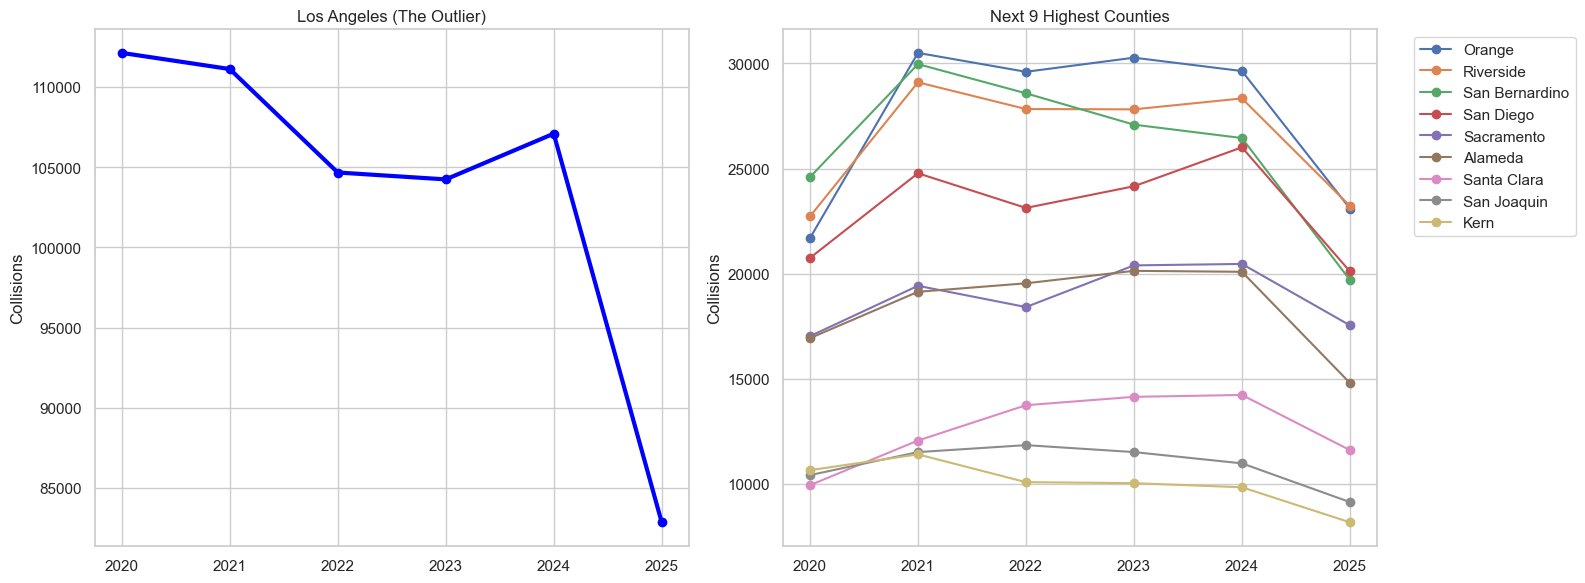

In [6]:
# Apply Map
df_crashes['County_Code'] = df_crashes['County_Code'].fillna(0).astype(int)
df_crashes["County_Name"] = df_crashes["County_Code"].map(county_map)
df_filtered = df_crashes[(df_crashes["Year"] >= 2020) & (df_crashes["Year"] <= 2025)]

# Aggregate
df_grouped = df_filtered.groupby(["County_Name", "Year"]).size().reset_index(name="num_collisions")

# Top 10 Counties
top10_list = df_grouped.groupby("County_Name")["num_collisions"].sum().nlargest(10).index.tolist()
df_plot = df_grouped[df_grouped["County_Name"].isin(top10_list)]
print(df_plot.pivot(index='County_Name', columns='Year', values='num_collisions'))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Los Angeles Outlier Plot
la_data = df_plot[df_plot["County_Name"] == "Los Angeles"].sort_values("Year")
ax1.plot(la_data["Year"], la_data["num_collisions"], marker='o', color='blue', linewidth=3)
ax1.set_title("Los Angeles (The Outlier)")
ax1.set_ylabel("Collisions")
ax1.grid(True)

# Next 9 Counties Plot
others = [c for c in top10_list if c != "Los Angeles"]
for county in others:
    c_data = df_plot[df_plot["County_Name"] == county].sort_values("Year")
    ax2.plot(c_data["Year"], c_data["num_collisions"], marker='o', label=county)
ax2.set_title("Next 9 Highest Counties")
ax2.set_ylabel("Collisions")
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True)
plt.tight_layout()
plt.show()

#### 3.2. Forecast Prediction for 2026
* **Note:** The data for the current year 2025 is incomplete. Policy decisions should be based on the 2020–2024 trends until 2025 data is finalized.

   Year  num_collisions
0  2020          374755
1  2021          422976
2  2022          405184
3  2023          409377
4  2024          414295
5  2025          325312
Predicted number of collisions in 2026: 365,077


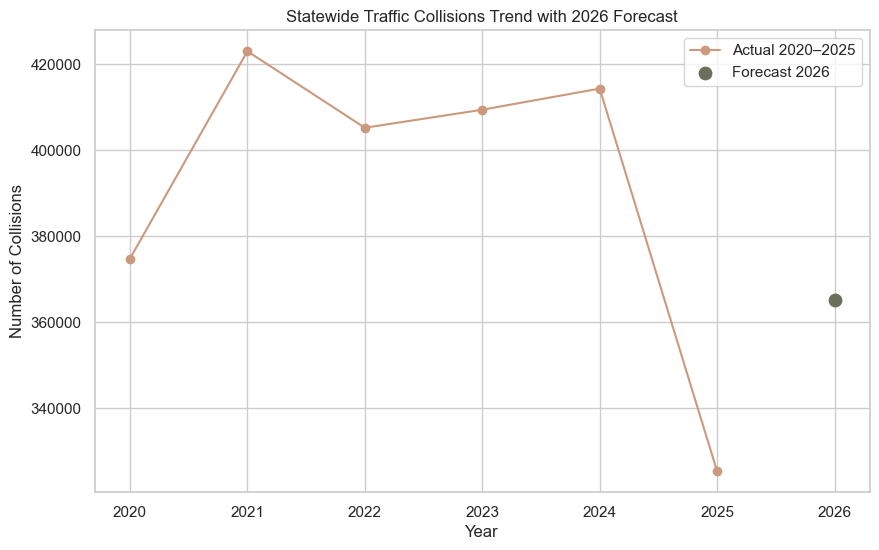

In [9]:
# Total collisions per year
trend_over_time = (
df_crashes.groupby("Year").size().reset_index(name="num_collisions")
)
print(trend_over_time)

# Linear regression
X = trend_over_time["Year"].values.reshape(-1, 1)
y = trend_over_time["num_collisions"].values
model = LinearRegression()
model.fit(X, y)

# Collision forecast for 2026
year_2026 = np.array([[2026]])
forecast_2026 = model.predict(year_2026)[0]
print(f"Predicted number of collisions in 2026: {forecast_2026:,.0f}")

# Plot
plt.figure(figsize=(10,6))
plt.plot(trend_over_time["Year"], trend_over_time["num_collisions"], 
marker="o", label="Actual 2020–2025", color="#CB997E")
plt.scatter([2026], [forecast_2026], color="#6B705C", label="Forecast 2026", s=80)
plt.title("Statewide Traffic Collisions Trend with 2026 Forecast")
plt.xlabel("Year")
plt.ylabel("Number of Collisions")
plt.grid(True)
plt.legend()
plt.show()


#### 3.3. Counties with Highest Collision Severity

Severity_Score     1.0    2.0    3.0   4.0   5.0
County_Name                                     
Los Angeles     171401  47598  17287  5415  1939
Orange           49621  14090   4706  1365   431
Riverside        42134  12057   4562  1450   509
San Bernardino   40955  11888   4652  1546   530
San Diego        55970  14201   4792  1396   437
Sacramento       33465   9573   3386   999   325
Alameda          29780   6654   2124   551   211
Santa Clara      26136   6398   1999   554   187
San Joaquin      16308   4532   1879   562   235
Kern             15015   4464   2158   763   276


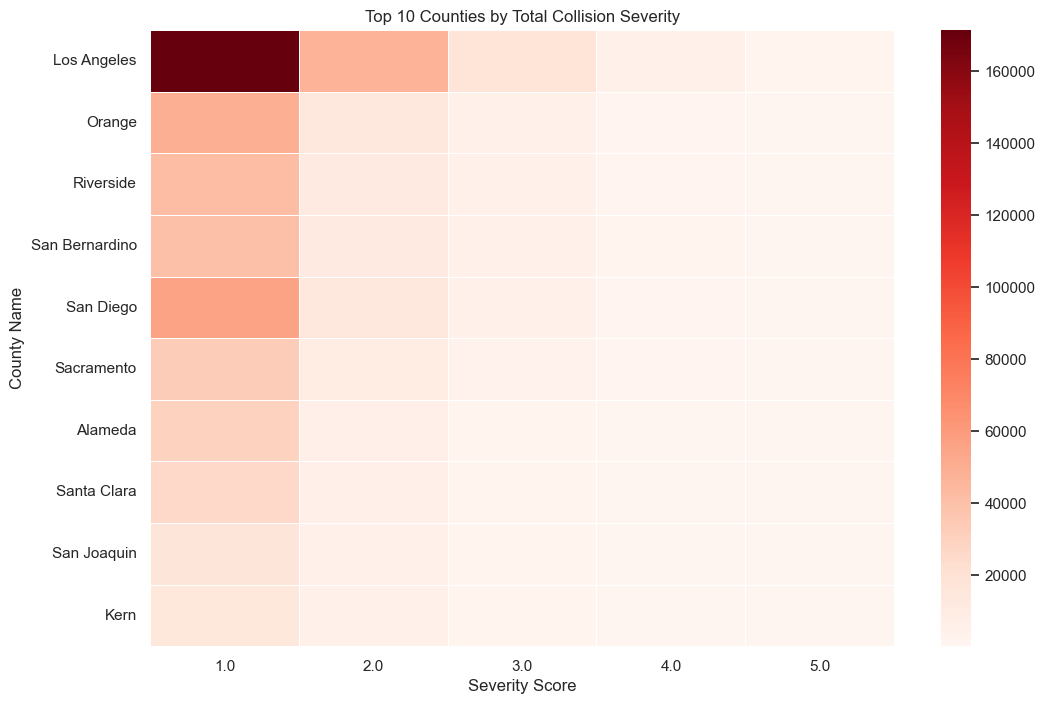

In [10]:
# Top 10 Counties by total volume
top10_counties = df_crashes['County_Name'].value_counts().nlargest(10).index.tolist()

# Filter Data for Severity Score between 1 and 5
heatmap_data = df_crashes[
    (df_crashes['Severity_Score'].between(1, 5)) & 
    (df_crashes['County_Name'].isin(top10_counties))
]

if not heatmap_data.empty:
    # Pivot Table
    pivot_table = pd.crosstab(heatmap_data['County_Name'], heatmap_data['Severity_Score'])
    pivot_table = pivot_table.loc[top10_counties]
    print(pivot_table)

    # Plot
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_table, cmap="Reds", linewidths=0.5, annot=False)
    plt.title("Top 10 Counties by Total Collision Severity")
    plt.xlabel("Severity Score")
    plt.ylabel("County Name")
    plt.show()
    

#### 3.4. Key Insights on Geographical Distribution of Collisions

**1. The Los Angeles Anomaly**
* **Observation:** Los Angeles County is a massive statistical outlier, consistently recording over 100,000 collisions annually. This volume is higher than the next five counties (Orange, Riverside, San Bernardino, San Diego, Sacramento) combined.

* **Trend Analysis:** While the Next 9 counties show similar patterns (a rise in 2021 followed by stabilization), LA's volume dictates the state average.

* **Data Note:** The sharp decline visible in 2025 across all charts suggests the 2025 dataset is currently incomplete. Policy decisions should prioritize the stable trends observed from 2021–2024.

**2. Statewide Forecast for 2026**
* **Observation:** After a peak in 2021 (~420k collisions) and a plateau around 410k, our model forecasts approximately 365,077 collisions for 2026.

* **Implication:** The model predicts a correction rather than a continuous drop. Authorities should budget resources for ~365k incidents next year, rather than assuming the incomplete 2025 low will persist.

**3. Severity vs. Frequency**
* **Observation:** The heatmap reveals that LA's massive collision count is overwhelmingly driven by Severity Score.

* **Insight:** The deep red intensity for LA fades quickly as severity scores increase (3.0–5.0). This suggests that LA's traffic problem is defined by frequency rather than strictly high-speed fatality events, whereas other counties might have higher proportional severity despite lower volume.

**Managerial Recommendations:**
1.  **In Los Angeles:** Deploy congestion management strategies (automated fines, lane assistance) to reduce the sheer volume of minor crashes.

2.  **Statewide:** Use the 2026 forecast of ~365k collisions to set the baseline for highway patrol staffing and emergency response budget allocation.

<a id="demographics"></a>
### **4. Demographics Distribution**

#### **Research Question 2:** How does collision involvement vary by age group and gender from 2020–2025, and which demographic groups contribute the most to overall collisions?

#### 4.1. Collisions by Age and Gender

GenderDescription  FEMALE    MALE  NON-BINARY  UNKNOWN
Age_Group                                             
0–17                17304   33148          15      295
18–25              187663  336733         238     1731
26–35              223374  412121         152     2026
36–50              236513  442993          81     2194
51–65              158052  321135          44     1676
65+                 74065  134318           8     1014


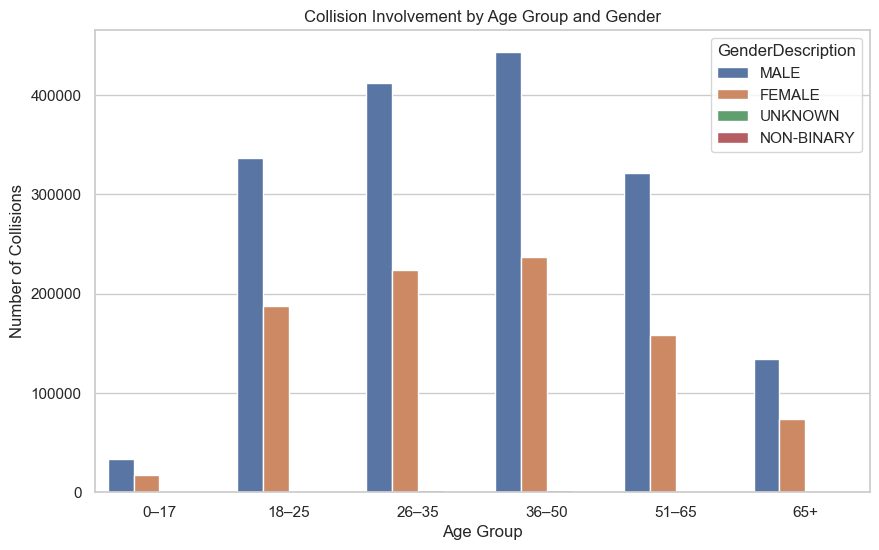

In [11]:
# Cleaning
df_master["StatedAge"] = pd.to_numeric(df_master["StatedAge"], errors="coerce")

# Create Bins
df_master["Age_Group"] = pd.cut(
    df_master["StatedAge"],
    bins=[0, 17, 25, 35, 50, 65, 120],
    labels=["0–17", "18–25", "26–35", "36–50", "51–65", "65+"],
    right=True
)
print(pd.crosstab(df_master["Age_Group"], df_master["GenderDescription"]))

# Plot
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_master,
    x="Age_Group",
    hue="GenderDescription"
)
plt.title("Collision Involvement by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Number of Collisions")
plt.show()

#### 4.2. Average Severity by Age Group

/var/folders/l6/vdcsyn8d1_jf1jgk0_sm23fc0000gn/T/ipykernel_1391/204888106.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Age_Group", "GenderDescription"])["Severity_Score"]


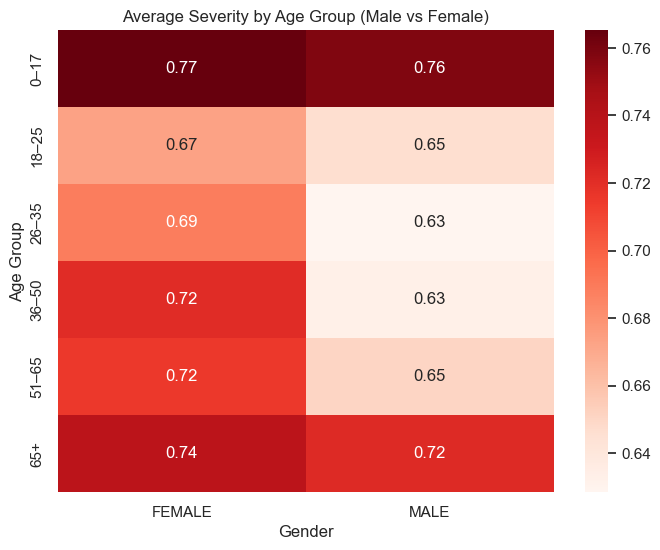

In [12]:
# Filtering
filtered = df_master[df_master["GenderDescription"].isin(["MALE", "FEMALE"])]

age_gender_sev = (
filtered.dropna(subset=["Age_Group", "GenderDescription", "Severity_Score"])
.groupby(["Age_Group", "GenderDescription"])["Severity_Score"]
.mean()
.unstack(fill_value=0)
)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(age_gender_sev, annot=True, fmt=".2f", cmap="Reds")
plt.title("Average Severity by Age Group (Male vs Female)")
plt.xlabel("Gender")
plt.ylabel("Age Group")
plt.show()

#### 4.3. Key Insights on Demographics Distribution of Collisions

**1. The Working Age Male Risk Factor**
* **Observation:** The collision frequency data reveals a distinct high-risk demographic: Males aged 26–50. This accounts for the highest volume of collisions, with the 36–50 age bracket alone recording over 440,000 incidents.

* **Gender Gap:** Across every age group, male drivers are involved in nearly double the number of collisions compared to female drivers.

* **Implication:** Collision volume is not primarily driven by inexperienced teenagers, but rather by the core workforce demographic.

**2. Youth Severity**
* **Observation:** While older males cause more crashes, younger drivers cause worse ones. The heatmap indicates that the 0–17 age group has the highest average severity scores regardless of gender.

* **Insight:** Severity drops significantly as drivers age into the 18–25 and 26–35 brackets, before creeping back up for drivers 65+.

* **Implication:** This confirms that while inexperience leads to fewer total crashes compared to working-age adults, the crashes that do occur involving amateur drivers are far more likely to result in injury or death.

**Managerial Recommendations:**
* To reduce Total Collision Volume, working males in the age group of 26–50 should be targeted with workplace road safety awareness programs.

* To reduce Fatalities and Major Injuries, teenage drivers should be targeted with stricter driving tests.

<a id="driver-behaviors"></a>
### **5. Driver Behaviors and Collision Factors**

#### **Research Question 3:** What are the primary collision factors associated with crashes, and how do environmental conditions impact safety?

#### 5.1. Top 5 Driver Behaviors Contributing to Crashes

Top Driver Behaviors
                     Behavior  Number_of_Crashes
0  Speeding (Basic Speed Law)             646609
1              Unsafe Turning             475437
2               DUI - Alcohol             149477
4          Unsafe Lane Change              81937
5         Red Light Violation              65478


/var/folders/l6/vdcsyn8d1_jf1jgk0_sm23fc0000gn/T/ipykernel_1391/531945620.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


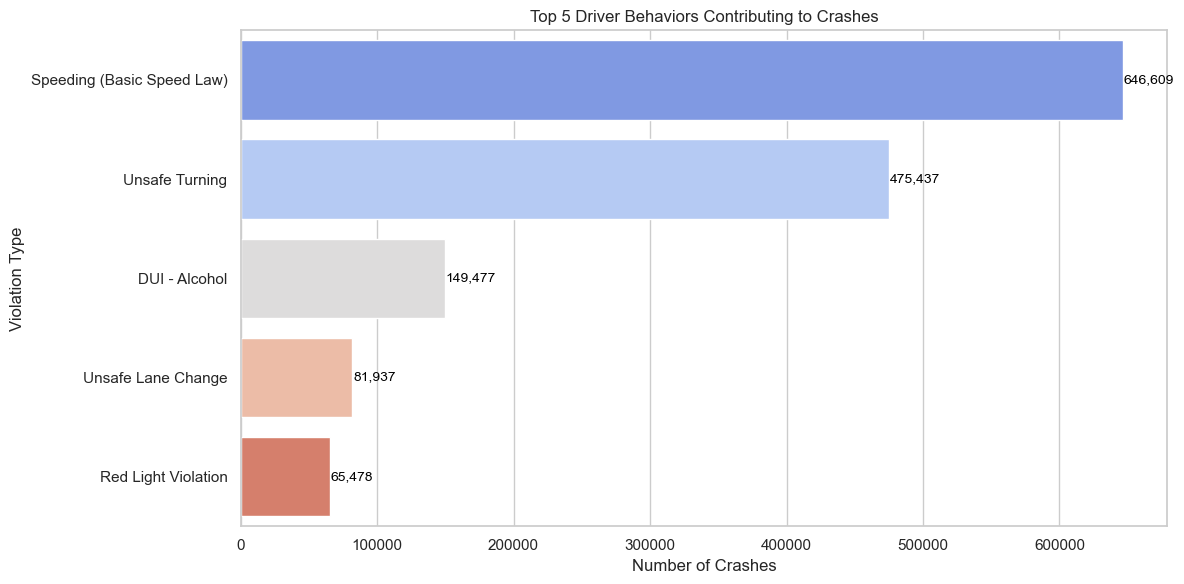

In [13]:
target_col = 'Primary_Collision_Factor_Violation'

if target_col in df_crashes.columns:
    clean_series = df_crashes[target_col].astype(str).str.strip()
    
    # Mapping
    df_crashes['Violation_Desc'] = clean_series.map(pcf_rename_map).fillna(clean_series)
    
    # Calculate Counts and Filter
    behavior_counts = df_crashes['Violation_Desc'].value_counts().reset_index()
    behavior_counts.columns = ['Behavior', 'Number_of_Crashes']
    behavior_counts = behavior_counts[~behavior_counts['Behavior'].isin(['-', 'Not Stated', 'nan'])]
    
    # Top 5 Driver Behaviors
    top_behaviors = behavior_counts.head(5)
    print("Top Driver Behaviors")
    print(top_behaviors)

    # Plot
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=top_behaviors,
        x='Number_of_Crashes',
        y='Behavior',
        palette='coolwarm'
    )
    for p in ax.patches:
        width = p.get_width()
        ax.text(
            width + 500,
            p.get_y() + p.get_height() / 2,
            f'{int(width):,}',
            ha='left', va='center', fontsize=10, color='black'
        )
    plt.title("Top 5 Driver Behaviors Contributing to Crashes")
    plt.xlabel("Number of Crashes")
    plt.ylabel("Violation Type")
    plt.tight_layout()
    plt.show()

#### 5.2. Top Primary Collision Factors by Average Severity Score

Top 5 Highest Severity Behaviors
                          Behavior  Avg_Severity
4336         Driving on Wrong Side     10.000000
4188   Crossed Double Yellow Lines      8.000000
4293                 DUI (Alcohol)      6.666667
4294                   DUI (Drugs)      6.500000
4996  Failure to Yield (Stop Sign)      6.000000


/var/folders/l6/vdcsyn8d1_jf1jgk0_sm23fc0000gn/T/ipykernel_1391/3980836971.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


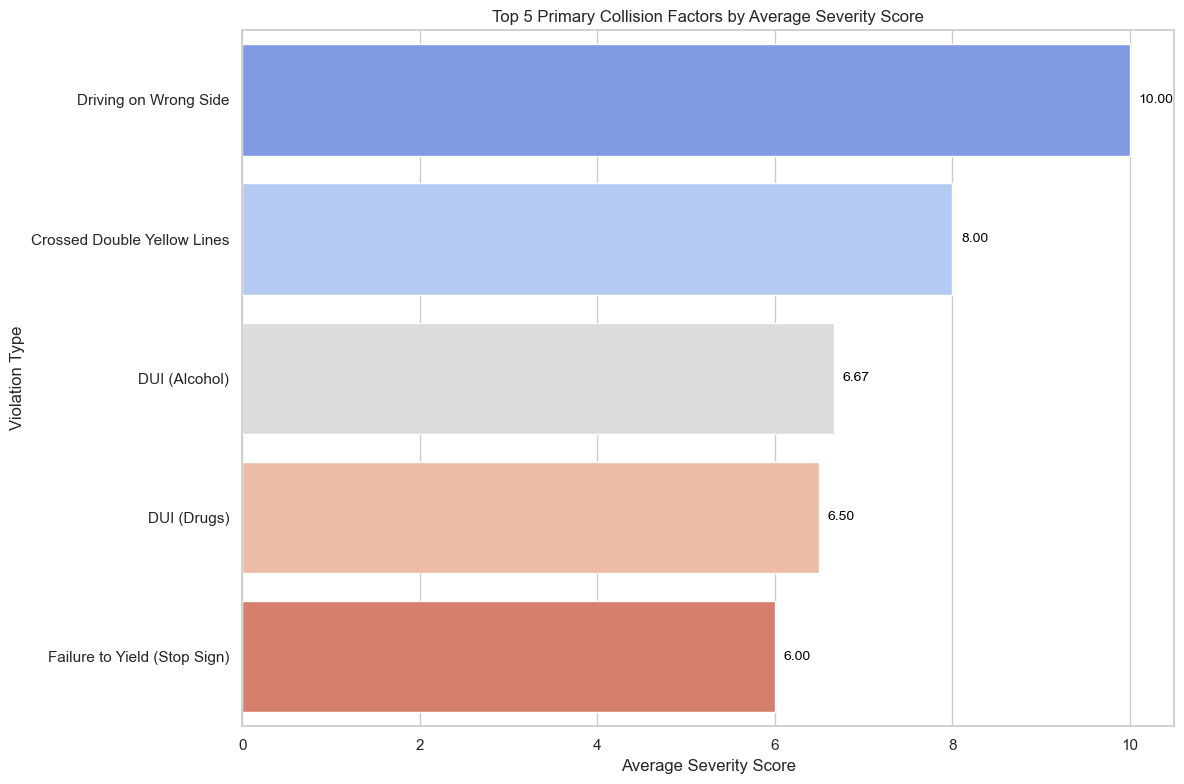

In [14]:
target_col = 'Primary_Collision_Factor_Violation'
if target_col in df_crashes.columns:
    
    # Mapping
    clean_series = df_crashes[target_col].astype(str).str.strip()
    df_crashes['Violation_Clean'] = clean_series.map(severity_map).fillna(clean_series)
    
    # Average Severity
    severity_stats = df_crashes.groupby('Violation_Clean')['Severity_Score'].mean().reset_index()
    severity_stats.columns = ['Behavior', 'Avg_Severity']
    
    # Top 5 highest severity by behavior
    top_sev_behaviors = severity_stats.sort_values('Avg_Severity', ascending=False).head(5)
    print("Top 5 Highest Severity Behaviors")
    print(top_sev_behaviors)

    # Plot
    plt.figure(figsize=(12, 8))
    ax = sns.barplot(
        data=top_sev_behaviors,
        x='Avg_Severity',
        y='Behavior',
        palette='coolwarm'
    )
    for p in ax.patches:
        width = p.get_width()
        ax.text(
            width + 0.1,
            p.get_y() + p.get_height() / 2,
            f'{width:.2f}',
            ha='left', va='center', fontsize=10, color='black'
        )

    plt.title("Top 5 Primary Collision Factors by Average Severity Score")
    plt.xlabel("Average Severity Score")
    plt.ylabel("Violation Type")
    plt.tight_layout()
    plt.show()

#### 5.3. Top 4 Lighting Conditions Contributing to Crashes

Top 4 Lighting Conditions Contributing to Crashes
      Lighting_Condition  Number_of_Crashes
0               DAYLIGHT            1474574
1     DARK-STREET LIGHTS             544620
2  DARK-NO STREET LIGHTS             231870
3              DUSK-DAWN              89892


/var/folders/l6/vdcsyn8d1_jf1jgk0_sm23fc0000gn/T/ipykernel_1391/2170864253.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


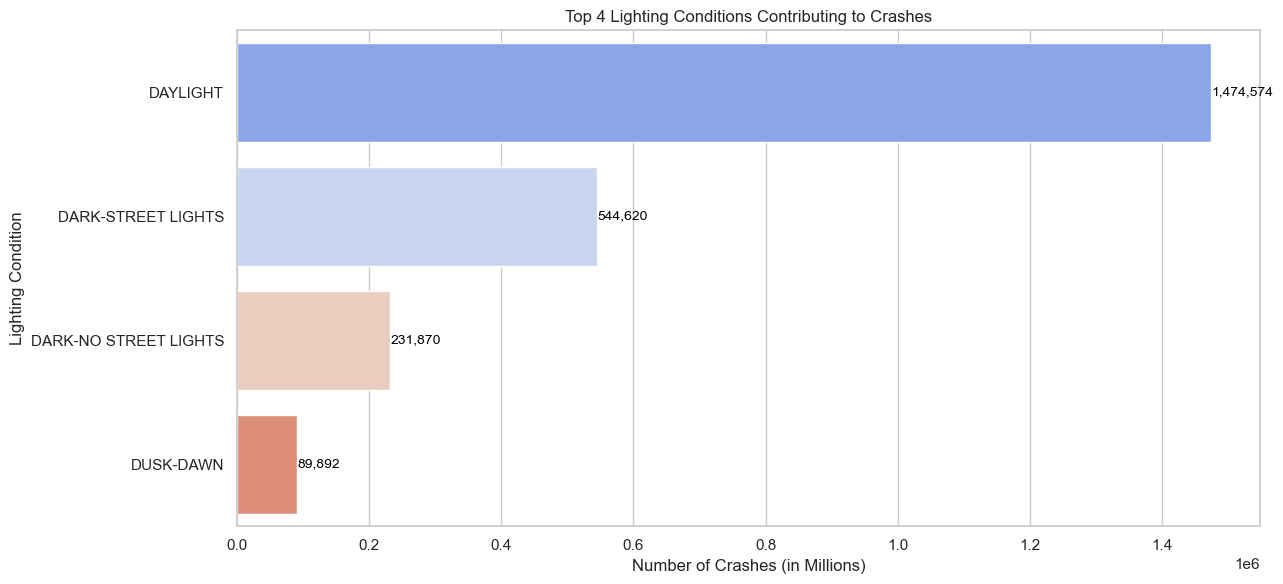

In [15]:
light_col = 'LightingDescription'

# Crashes by lighting condition
light_counts = df_crashes[light_col].value_counts().reset_index()
light_counts.columns = ['Lighting_Condition', 'Number_of_Crashes']
light_counts = light_counts[~light_counts['Lighting_Condition'].isin(['-', 'Not Stated'])]

# Top 4 crashes by lighting condition
top_lighting = light_counts.head(4)
print("Top 4 Lighting Conditions Contributing to Crashes")
print(top_lighting)

# Plot
plt.figure(figsize=(13, 6))
ax = sns.barplot(
    data=top_lighting,
    x='Number_of_Crashes',
    y='Lighting_Condition',
    palette='coolwarm'
)
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 500,     
        p.get_y() + p.get_height() / 2, 
        f'{int(width):,}', 
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )
plt.title("Top 4 Lighting Conditions Contributing to Crashes")
plt.xlabel("Number of Crashes (in Millions)")
plt.ylabel("Lighting Condition")
plt.tight_layout()
plt.show()

#### 5.4. Top 5 Weather Conditions Contributing to Crashes

Top 5 Crash Counts by Weather
  Weather_Condition  Number_of_Crashes
0             CLEAR            2033001
1            CLOUDY             223669
2           RAINING              68354
3    FOG/VISIBILITY               8446
4           SNOWING               2727


/var/folders/l6/vdcsyn8d1_jf1jgk0_sm23fc0000gn/T/ipykernel_1391/2027028003.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


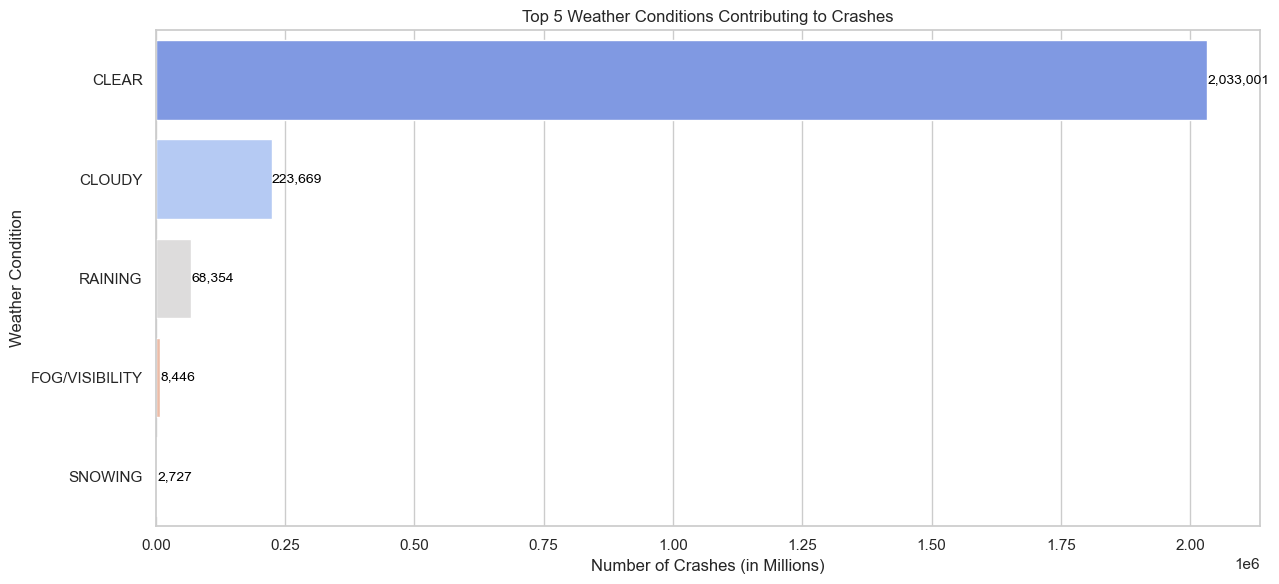

In [16]:
weather_col = 'Weather_1'

if weather_col in df_crashes.columns:

    # Count crashes by weather condition
    weather_counts = df_crashes[weather_col].value_counts().reset_index()
    weather_counts.columns = ['Weather_Condition', 'Number_of_Crashes']
    weather_counts = weather_counts[~weather_counts['Weather_Condition'].isin(['-', 'Not Stated'])]

    # Top 5 Crashes by weather condition
    top_weather = weather_counts.head(5)
    print("Top 5 Crash Counts by Weather")
    print(top_weather)

    # Plot
    plt.figure(figsize=(13, 6))
    ax = sns.barplot(
        data=top_weather,
        x='Number_of_Crashes',
        y='Weather_Condition',
        palette='coolwarm'
    )
    for p in ax.patches:
        width = p.get_width() 
        ax.text(
            width + 500,    
            p.get_y() + p.get_height() / 2, 
            f'{int(width):,}', 
            ha='left',         
            va='center',       
            fontsize=10,
            color='black'
        )
    plt.title("Top 5 Weather Conditions Contributing to Crashes")
    plt.xlabel("Number of Crashes (in Millions)")
    plt.ylabel("Weather Condition")
    plt.tight_layout()
    plt.show()

#### 5.5. Total Crashes by Hour of Day

Total Collisions by Hour
    Hour  Crash_Count
0      0        85215
1      1        51633
2      2        49390
3      3        37001
4      4        36742
5      5        50989
6      6        67410
7      7       100011
8      8       111331
9      9        89151
10    10        93197
11    11       105322
12    12       120105
13    13       126399
14    14       145387
15    15       165096
16    16       160639
17    17       168999
18    18       141083
19    19       109093
20    20        97423
21    21        91419
22    22        80454
23    23        68410


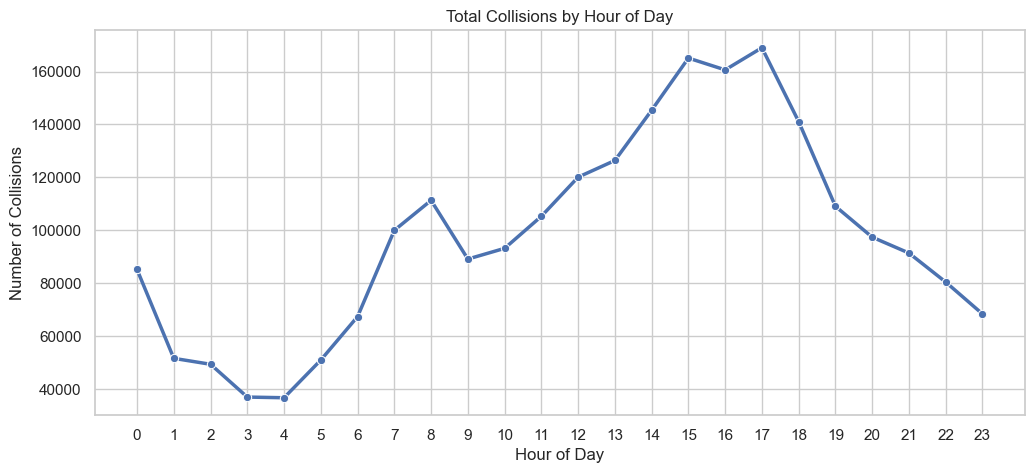

In [17]:
# Crashes per Hour
hourly_counts = df_crashes['Hour'].value_counts().sort_index().reset_index()
hourly_counts.columns = ['Hour', 'Crash_Count']
print("Total Collisions by Hour")
print(hourly_counts)

# Plot
plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_counts, x='Hour', y='Crash_Count', marker='o', linewidth=2.5)
plt.title("Total Collisions by Hour of Day")
plt.xticks(range(0, 24))
plt.grid(True)
plt.ylabel("Number of Collisions")
plt.xlabel("Hour of Day")
plt.show()

#### 5.6. Key Insights on Driver Behaviors and Collision Factors

**1. The Frequency vs. Severity Paradox**
* **Volume of Drivers:** The sheer volume of collisions in California is driven by routine traffic violations. Speeding is the dominant cause, responsible for nearly 650k incidents, followed by Unsafe Turning (~475k). These behaviors represent impatience and congestion-related errors.

* **Dangerous Drivers:** However, the behaviors that cause the deadliest crashes are different. Driving on the Wrong Side of the Road has an alarming average severity score of 10.0 indicating high fatality/injury rates.

* **Implication:** Speeding makes the roads unsafe due to volume, but lane violations and impairment cause the most loss of life.

**2. Human Errors Outweigh Environmental Risks**
* **Observation:** Contrary to our assumption that bad weather causes crashes, the data shows that the vast majority of collisions occur during Clear Weather(~2M) and Daylight (~1.5M).

* **Work Commute Factor:** The crash timeline reveals distinct peaks during standard commute hours (morning and evening rush), confirming that raffic density is the primary driver of collision volume, not environmental hazards.

* **Insight:** The greatest risk on the road is not rain or darkness. Clear, sunny days creates more opportunities for human error.

**Managerial Recommendation:**
1.  **To combat volume of accidents:** Implement automated traffic enforcement such as speed cameras in high-density urban areas where police stops are inefficient.

2.  **To combat severity of crashes:** Invest in infrastructure such as center median barriers and speed bumps on undivided highways to prevent wrong side driving.

<a id="conclusion"></a>
### **6. Conclusion**

#### Summary of Findings
* **Geographic Distribution:** Los Angeles County is a statistical outlier, accounting for over 25% of the state's total collision volume. However, its severity profile is dominated by minor incidents, whereas other counties show higher proportional severity despite lower volume.

* **Demographic Information:** The data challenges the stereotype that inexperienced teenagers are the primary problem. The largest contributor to collision volume is the core workforce which is Males aged 26–50. However, the 0–17 age group records the highest average severity, confirming that while youth cause fewer crashes, they are far more dangerous when they occur.

* **Driver Behaviors:** Speeding and Unsafe Turning are the primary causes of collision volume. However, Driving on the Wrong Side of the Road and DUI are the primary drivers of fatalities. Furthermore, human errors outweigh environmental factors, with the vast majority of incidents occurring during clear weather and in daylight.

#### Managerial Insights & Recommendations
Based on these findings, we propose the following actionable strategies to improve road safety:

1.  **Automated Enforcement:** Add cameras in speeding hotspots (especially in high-volume counties like Los Angeles) to reduce speeding violations that manual police enforcement cannot handle.
2.  **Physical Infrastructure:** Install physical lane separators to prevent wrong side driving collisions and add speed bumps to force behavioral changes in drivers.

3.  **Vulnerable Road Users:** Improve pedestrian crossings with high-visibility markings, particularly in urban areas where intersection-related crashes are frequent.

4.  **Visibility & Maintenance:** Increase lighting in rural and suburban counties and prioritize lane marking maintenance. Clear lane visibility is critical for preventing Unsafe Lane Change accidents.

5.  **Long-Term Strategy:** Invest in infrastructure and public transportation alternatives. Reducing overall vehicle dependency is the only way to significantly lower the number of traffic accidents for 2026 and beyond.